### TF-IDF가 중요한 이유
- 문서에 자주 나오는 단어가 항상 중요한 단어는 아니다
- 이 문서에는 자주 나오지만 다른 문서에는 드문 단어가 이 문서의 핵심 단어
- 예) 기자라는 단어는 어느 뉴스 본문에나 등장하지만 별로 중요하지 않음 -> 불용어
- 문서의 핵심 단어 추출에 쓰임 -> 검색(BM25) 하이브리드 RAG 구축, 임베딩에 쓰이는 개념

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

from kiwipiepy import Kiwi
kiwi = Kiwi()
df = pd.read_csv("../data/11-1_뉴스정제.csv")

In [13]:
# 명사 추출 함수 만들기

def extract_nouns(text):
    nouns = []
    result = kiwi.tokenize(text)

    for token in result:
        if token.tag.startswith("N"):
            nouns.append(token.form)

    nouns_filtered = []

    for noun in nouns:
        if len(noun) > 1:
            nouns_filtered.append(noun)

    return nouns_filtered

### 1. TF-IDF 개념
- TF(단어 빈도): 한 문서에서 그 단어가 자주 나올수록 높다
- IDF(역문서 빈도): 그 단어가 여러 문서에 흔할수록 낮아진다(흔한 단어에 패널티)
- TF-IDF는 TF와 IDF 곱한 값 -> 이 문서에는 자주 나오지만 다른 문서에는 드물수록 점수 높음

In [17]:
docs = [
        "자동차 가격 자동차",   # 문서 1
        "자동차 가격 가격",     # 문서 2
        "날씨 날씨 자동차"      # 문서 3
        ]

vocab = ['자동차', '가격', '날씨']


data = pd.DataFrame({
    "자동차" : [2,1,1],
    "가격" : [1,1,0],
    "날씨" : [0,0,2]
})
data

,자동차,가격,날씨
0,2,1,0
1,1,1,0
2,1,0,2


In [18]:
import numpy as np

# 전체 문서수
N = 3
df_ = (data > 0).sum()    # 각 단어가 등장한 문서 수

idf = np.log(N / df_)
idf

자동차    0.000000
가격     0.405465
날씨     1.098612
dtype: float64

In [ ]:
# scikit-learn 패키지를 이용해서 TF-IDF 구하기
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(tokenizer=extract_nouns, token_pattern=None)
X = vec.fit_transform(df['정제본문'])

In [22]:
X.data

array([0.42364895, 0.20512122, 0.46909573, ..., 0.05303473, 0.05303473,
       0.05303473], shape=(100830,))

In [24]:
feature_words = vec.get_feature_names_out()
print(feature_words)

['1이더리움' '2여객터미널' '3사' ... '힘겨루기' '힙밥' '힙합']


In [25]:
print("문서 수 x 단어 수", X.shape)

문서 수 x 단어 수 (1000, 14444)


In [26]:
# 한 기사에서 가장 TF-IDF가 높은 단어를 찾아보는 함수 만들어보기

def keywords(doc_idx, count=5):     # 문서의 인덱스를 받아서 가장 높은 단어를 몇 개 볼지 정해주는 함수
    row = X[doc_idx].toarray()[0]
    top = row.argsort()[-count:][::-1]
    return [feature_words[i] for i in top]

In [27]:
keywords(0)

['현대백화점그룹', '광주광역시', '서울', '여의도', '현대']

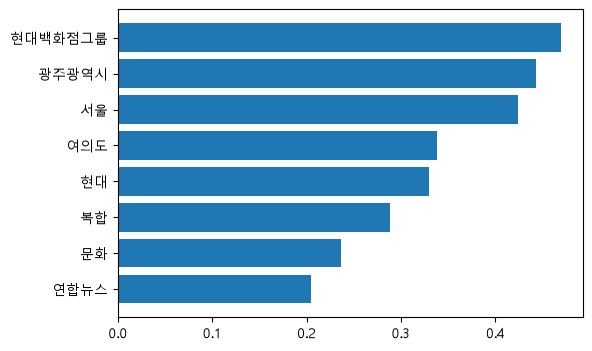

In [28]:
# 핵심어들을 그래프로 보기
row = X[0].toarray()[0]
top = row.argsort()[-8:][::-1] # 정렬 -> 뒤에서 8개 -> 뒤집으면 가장 제일 상단에 핵심어
scores = [row[i] for i in top]
picked_words = [feature_words[i] for i in top]

plt.figure(figsize=(6,4))
plt.barh(picked_words[::-1], scores[::-1])  # ::-1 , 시작점:끝점:간격
plt.show()

In [31]:
pd.DataFrame(X.data)

,0
0,0.423649
1,0.205121
2,0.469096
3,0.442736
4,0.338104
...,...
100825,0.053035
100826,0.053035
100827,0.053035
100828,0.053035


#### 문서별 단어 TF-IDF 였는데 
- 각 문서가 얼마나 유사한가
- 코사인 유사도로 계산